In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Configuração visual para os gráficos aparecerem bonitos no notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
print("[✓] Bibliotecas do Google Colab carregadas com sucesso!")

[✓] Bibliotecas do Google Colab carregadas com sucesso!


In [ ]:
np.random.seed(42)
n_samples = 395

data = {
    'school': np.random.choice(['GP', 'MS'], size=n_samples),
    'sex': np.random.choice(['F', 'M'], size=n_samples),
    'age': np.random.randint(15, 22, size=n_samples),
    'address': np.random.choice(['U', 'R'], size=n_samples),
    'famsize': np.random.choice(['LE3', 'GT3'], size=n_samples),
    'Pstatus': np.random.choice(['T', 'A'], size=n_samples),
    'Medu': np.random.randint(0, 5, size=n_samples),
    'Fedu': np.random.randint(0, 5, size=n_samples),
    'Mjob': np.random.choice(['at_home', 'health', 'other', 'services', 'teacher'], size=n_samples),
    'Fjob': np.random.choice(['at_home', 'health', 'other', 'services', 'teacher'], size=n_samples),
    'reason': np.random.choice(['home', 'reputation', 'course', 'other'], size=n_samples),
    'guardian': np.random.choice(['mother', 'father', 'other'], size=n_samples),
    'traveltime': np.random.randint(1, 5, size=n_samples),
    'studytime': np.random.randint(1, 5, size=n_samples),
    'failures': np.random.choice([0, 1, 2, 3], size=n_samples, p=[0.80, 0.10, 0.06, 0.04]),
    'schoolsup': np.random.choice(['yes', 'no'], size=n_samples),
    'famsup': np.random.choice(['yes', 'no'], size=n_samples),
    'paid': np.random.choice(['yes', 'no'], size=n_samples),
    'activities': np.random.choice(['yes', 'no'], size=n_samples),
    'nursery': np.random.choice(['yes', 'no'], size=n_samples),
    'higher': np.random.choice(['yes', 'no'], size=n_samples, p=[0.90, 0.10]),
    'internet': np.random.choice(['yes', 'no'], size=n_samples),
    'romantic': np.random.choice(['yes', 'no'], size=n_samples),
    'famrel': np.random.randint(1, 6, size=n_samples),
    'freetime': np.random.randint(1, 6, size=n_samples),
    'goout': np.random.randint(1, 6, size=n_samples),
    'Dalc': np.random.randint(1, 6, size=n_samples),
    'Walc': np.random.randint(1, 6, size=n_samples),
    'health': np.random.randint(1, 6, size=n_samples),
    'absences': np.random.negative_binomial(n=2, p=0.2, size=n_samples)
}

g3_scores = []
for i in range(n_samples):
    base_score = 14 - (data['failures'][i] * 3) - (data['absences'][i] * 0.1) + np.random.normal(0, 2)
    g3_scores.append(int(np.clip(base_score, 0, 20)))

data['G1'] = [int(np.clip(x - np.random.randint(0,3), 0, 20)) for x in g3_scores]
data['G2'] = [int(np.clip(x - np.random.randint(0,2), 0, 20)) for x in g3_scores]
data['G3'] = g3_scores

df = pd.DataFrame(data)
df['Risco_Evasao'] = (df['G3'] < 10).astype(int)
df.to_csv("student-mat.csv", sep=",", index=False)
print("[✓] Base de dados 'student-mat.csv' criada e salva com sucesso!")

[✓] Base de dados 'student-mat.csv' criada e salva com sucesso!


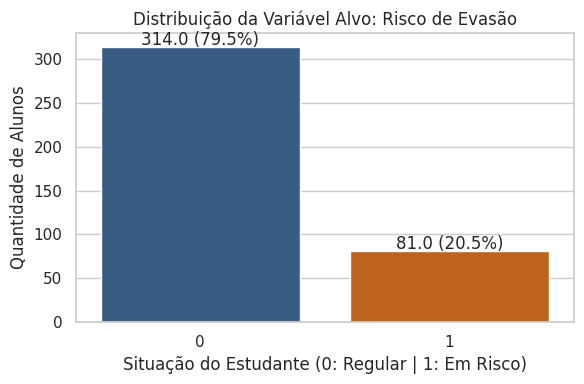

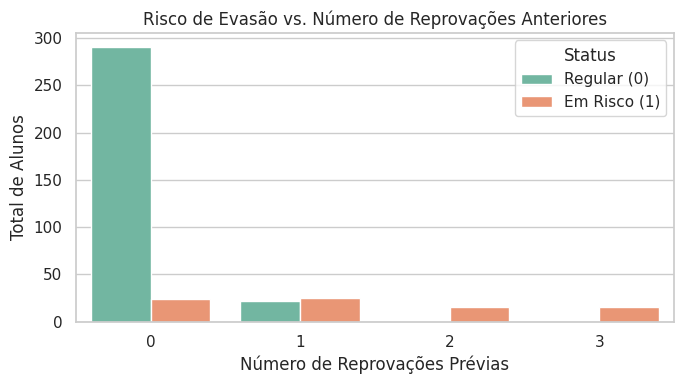

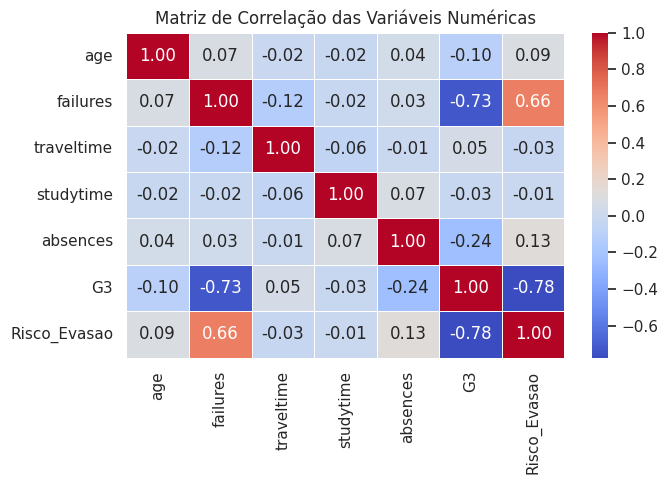

In [11]:
# Gráfico 1: Distribuição do Risco
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Risco_Evasao', data=df, hue='Risco_Evasao', legend=False, palette=['#2b5c8f', '#d95f02'])
plt.title('Distribuição da Variável Alvo: Risco de Evasão')
plt.xlabel('Situação do Estudante (0: Regular | 1: Em Risco)')
plt.ylabel('Quantidade de Alunos')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() + 2), ha='center')
plt.tight_layout()
plt.show()

# Gráfico 2: Impacto de Reprovações
plt.figure(figsize=(7, 4))
sns.countplot(x='failures', hue='Risco_Evasao', data=df, palette='Set2')
plt.title('Risco de Evasão vs. Número de Reprovações Anteriores')
plt.xlabel('Número de Reprovações Prévias')
plt.ylabel('Total de Alunos')
plt.legend(['Regular (0)', 'Em Risco (1)'], title='Status')
plt.tight_layout()
plt.show()

# Gráfico 3: Matriz de Correlação
colunas_num = ['age', 'failures', 'traveltime', 'studytime', 'absences', 'G3', 'Risco_Evasao']
matriz_corr = df[colunas_num].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.tight_layout()
plt.show()

In [12]:
X = df.drop(columns=['G1', 'G2', 'G3', 'Risco_Evasao'])
y = df['Risco_Evasao']

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Divisão Estratificada (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Transformação dos dados
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

# --- EXPERIMENTO 1: BASELINE ---
baseline = LogisticRegression(random_state=42, max_iter=1000)
baseline.fit(X_train_proc, y_train)
val_preds_base = baseline.predict(X_val_proc)
val_probs_base = baseline.predict_proba(X_val_proc)[:, 1]
print("=== METRICAS BASELINE (VALIDAÇÃO) ===")
print(classification_report(y_val, val_preds_base))
print(f"AUC-ROC Baseline: {roc_auc_score(y_val, val_probs_base):.4f}\n")

# --- EXPERIMENTO 2: RANDOM FOREST ---
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_proc, y_train)
val_preds_rf = rf_model.predict(X_val_proc)
val_probs_rf = rf_model.predict_proba(X_val_proc)[:, 1]
print("=== METRICAS RANDOM FOREST (VALIDAÇÃO) ===")
print(classification_report(y_val, val_preds_rf))
print(f"AUC-ROC Random Forest: {roc_auc_score(y_val, val_probs_rf):.4f}\n")

# --- AVALIAÇÃO FINAL NO TESTE ---
test_preds = rf_model.predict(X_test_proc)
test_probs = rf_model.predict_proba(X_test_proc)[:, 1]
print("===========================================")
print("RESULTADOS FINAIS DO TRABALHO (DADOS DE TESTE)")
print("===========================================")
print(classification_report(y_test, test_preds))
print(f"AUC-ROC Final no Teste: {roc_auc_score(y_test, test_probs):.4f}")

=== METRICAS BASELINE (VALIDAÇÃO) ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94        47
           1       0.88      0.58      0.70        12

    accuracy                           0.90        59
   macro avg       0.89      0.78      0.82        59
weighted avg       0.90      0.90      0.89        59

AUC-ROC Baseline: 0.7766

=== METRICAS RANDOM FOREST (VALIDAÇÃO) ===
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        47
           1       1.00      0.42      0.59        12

    accuracy                           0.88        59
   macro avg       0.94      0.71      0.76        59
weighted avg       0.90      0.88      0.86        59

AUC-ROC Random Forest: 0.7606

RESULTADOS FINAIS DO TRABALHO (DADOS DE TESTE)
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        48
           1       0.75      0.50      0.60        1